# 📈 Polynomial Regression

> **Folder:** `03_Supervised_Learning / Regression / Polynomial_Regression`  
> **Notebook:** `polynomial_regression.ipynb`  
> **Author:** Hamna Munir

---

## 🎯 Objectives

By the end of this notebook, you will:

- Understand **why polynomial regression** is needed when linear relationships fail
- Transform features using **PolynomialFeatures** from sklearn
- Fit **degrees 1 through 10** and compare bias-variance tradeoff
- Visualize **underfitting, good fit, and overfitting**
- Evaluate with **MAE, RMSE, R², Adjusted R²**
- Use **K-Fold Cross-Validation** to select the optimal degree
- Understand and plot the **Bias-Variance Tradeoff**
- Combine **PolynomialFeatures + Ridge Regularization** to combat overfitting
- Build a clean **sklearn Pipeline** for the full workflow

---

## 📚 Sections

| # | Section | Key Concept |
|---|---------|-------------|
| 1 | Dataset Creation & EDA | Non-linear data generation |
| 2 | Why Not Linear? | Visualizing linear failure |
| 3 | PolynomialFeatures Transform | Feature expansion |
| 4 | Degree Comparison | Degrees 1–10 |
| 5 | Overfitting vs Underfitting | Visual + metric evidence |
| 6 | Evaluation Metrics | MAE, RMSE, R², Adj R² |
| 7 | Bias-Variance Tradeoff | Train vs test error curves |
| 8 | Cross-Validation | Optimal degree selection |
| 9 | Polynomial + Ridge | Regularization against overfitting |
| 10 | Multi-Feature Polynomial | Interaction terms |
| 11 | Pipeline | Scale + Poly + Fit workflow |
| 12 | Summary & Best Practices | Key takeaways |

---
## ⚙️ 0. Setup & Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import statsmodels.api as sm

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error,
    r2_score, mean_absolute_percentage_error
)
from sklearn.pipeline import Pipeline
from scipy import stats

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)

COLORS = {
    'primary'  : '#2E86AB',
    'secondary': '#E84855',
    'accent'   : '#3BB273',
    'warning'  : '#F18F01',
    'palette'  : ['#2E86AB','#E84855','#3BB273','#F18F01','#7B2D8B',
                  '#C73E1D','#3D5A80','#98C1D9','#E0FBFC','#44BBA4'],
}

print('✅ Libraries loaded successfully!')

✅ Libraries loaded successfully!


---
## 📊 1. Dataset Creation & EDA

> We simulate a **non-linear salary dataset** where salary grows quadratically with experience  
> (early career growth is slow, mid-career accelerates, senior plateau begins).

In [2]:
np.random.seed(42)
n = 300

# Single-feature dataset for clean polynomial visualization
experience = np.sort(np.random.uniform(0, 20, n))

# True non-linear (cubic) relationship
salary = (
    30_000
    + 1_000  * experience
    + 300    * experience**2
    - 8      * experience**3
    + np.random.normal(0, 5_000, n)
)

df = pd.DataFrame({
    'Experience': experience,
    'Salary'    : salary.astype(int),
})

X = df[['Experience']]
y = df['Salary']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Shape  : {df.shape}')
print(f'Train  : {X_train.shape} | Test: {X_test.shape}')
df.describe().T

Shape  : (300, 2)
Train  : (240, 1) | Test: (60, 1)


,count,mean,std,min,25%,50%,75%,max
Experience,300.0000,9.9041,5.8868,0.1012,4.7816,10.2344,15.1372,19.8011
Salary,300.0000,63637.5133,24409.5050,16667.0000,42327.7500,61531.5000,84877.2500,108289.0000


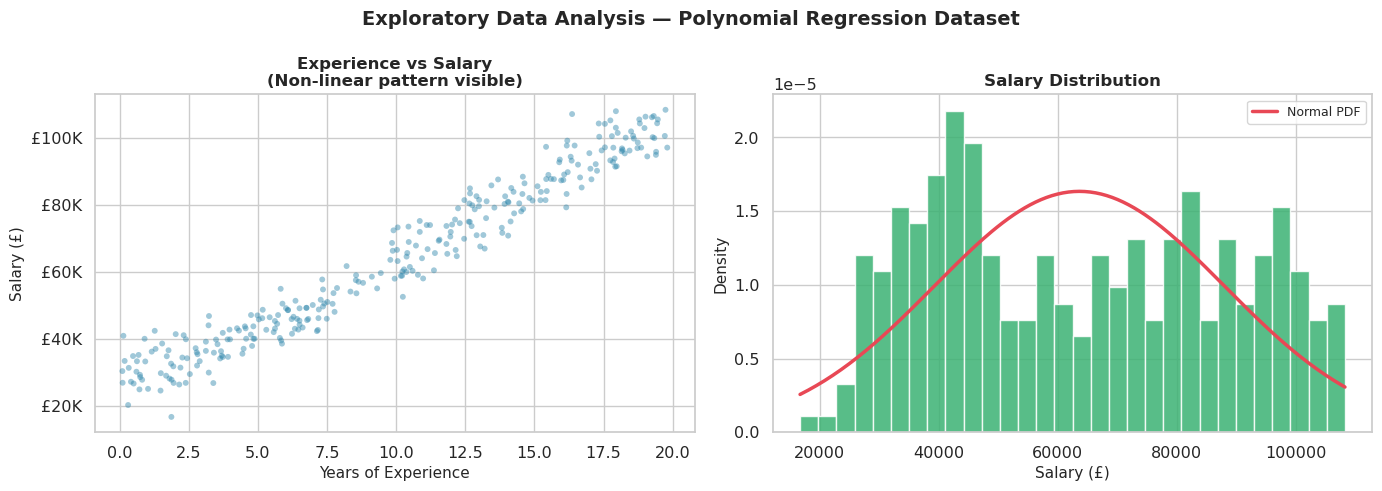

In [3]:
# ── Raw scatter plot — show non-linear pattern ────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter
axes[0].scatter(df['Experience'], df['Salary'],
                color=COLORS['primary'], alpha=0.45, s=18, edgecolors='none')
axes[0].set_xlabel('Years of Experience', fontsize=11)
axes[0].set_ylabel('Salary (£)', fontsize=11)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x/1000:.0f}K'))
axes[0].set_title('Experience vs Salary\n(Non-linear pattern visible)', fontsize=12, fontweight='bold')

# Distribution of salary
axes[1].hist(df['Salary'], bins=30, color=COLORS['accent'],
              edgecolor='white', alpha=0.85, density=True)
x_norm = np.linspace(df['Salary'].min(), df['Salary'].max(), 200)
axes[1].plot(x_norm,
              stats.norm.pdf(x_norm, df['Salary'].mean(), df['Salary'].std()),
              color=COLORS['secondary'], linewidth=2.5, label='Normal PDF')
axes[1].set_xlabel('Salary (£)', fontsize=11)
axes[1].set_ylabel('Density', fontsize=11)
axes[1].set_title('Salary Distribution', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=9)

plt.suptitle('Exploratory Data Analysis — Polynomial Regression Dataset',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 2️⃣ Why Not Linear Regression?

> A straight line cannot capture curves.  
> Forcing a linear fit on non-linear data → **systematic bias in residuals**.
>
> ✅ This motivates adding polynomial (squared, cubed, …) terms.

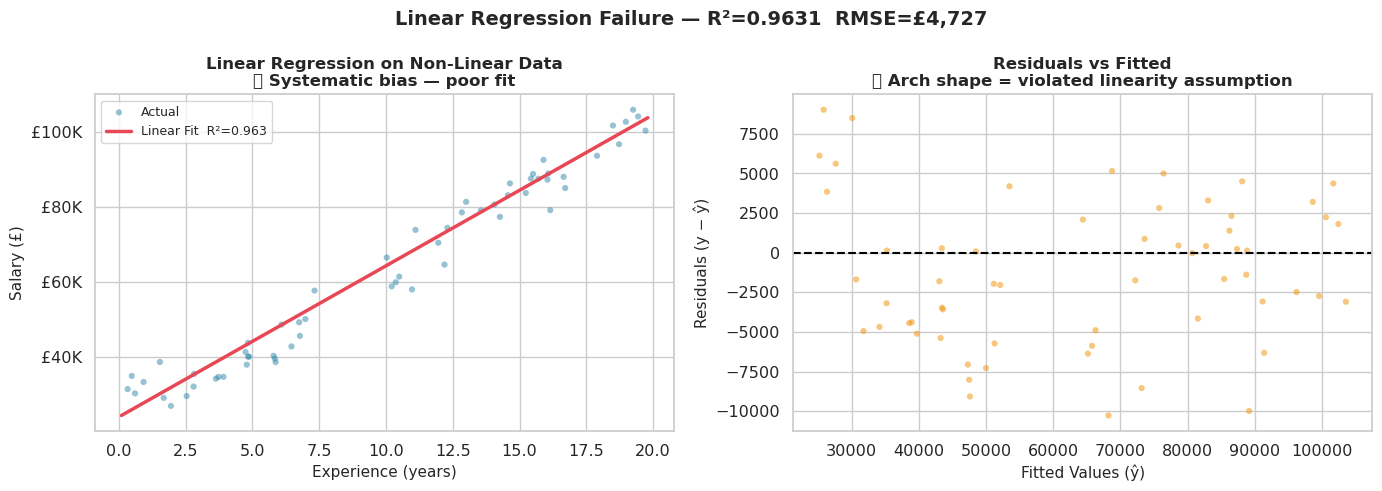

Linear Model — Test R²: 0.9631  |  RMSE: £4,727


In [4]:
# ── Fit a plain linear model ──────────────────────────────────────────────
lin_model = LinearRegression()
lin_model.fit(X_train, y_train)
y_lin_pred = lin_model.predict(X_test)

lin_r2   = r2_score(y_test, y_lin_pred)
lin_rmse = np.sqrt(mean_squared_error(y_test, y_lin_pred))

x_plot = np.linspace(X['Experience'].min(), X['Experience'].max(), 300).reshape(-1, 1)
y_lin_line = lin_model.predict(x_plot)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Fit plot
axes[0].scatter(X_test, y_test,
                color=COLORS['primary'], alpha=0.50, s=20, edgecolors='none', label='Actual')
axes[0].plot(x_plot, y_lin_line,
              color=COLORS['secondary'], linewidth=2.5, label=f'Linear Fit  R²={lin_r2:.3f}')
axes[0].set_xlabel('Experience (years)', fontsize=11)
axes[0].set_ylabel('Salary (£)', fontsize=11)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x/1000:.0f}K'))
axes[0].set_title('Linear Regression on Non-Linear Data\n❌ Systematic bias — poor fit',
                   fontsize=12, fontweight='bold')
axes[0].legend(fontsize=9)

# Residual plot — should show systematic U-shape / arch
lin_resid = y_test.values - y_lin_pred
axes[1].scatter(y_lin_pred, lin_resid,
                color=COLORS['warning'], alpha=0.50, s=20, edgecolors='none')
axes[1].axhline(0, color='black', linewidth=1.5, linestyle='--')
axes[1].set_xlabel('Fitted Values (ŷ)', fontsize=11)
axes[1].set_ylabel('Residuals (y − ŷ)', fontsize=11)
axes[1].set_title('Residuals vs Fitted\n❌ Arch shape = violated linearity assumption',
                   fontsize=12, fontweight='bold')

plt.suptitle(f'Linear Regression Failure — R²={lin_r2:.4f}  RMSE=£{lin_rmse:,.0f}',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Linear Model — Test R²: {lin_r2:.4f}  |  RMSE: £{lin_rmse:,.0f}')

---
## 3️⃣ PolynomialFeatures Transform

> **Key idea:** extend the feature matrix with polynomial terms.
>
> For degree=2 with 1 feature `x`:  
> `[x]` → `[1, x, x²]`
>
> For degree=3:  
> `[x]` → `[1, x, x², x³]`
>
> Then we apply **plain Linear Regression** on the expanded features —  
> the model is still linear in its parameters (β), just non-linear in x.
>
> ✅ `PolynomialFeatures` does the expansion automatically.

In [5]:
# ── Demonstrate feature expansion ────────────────────────────────────────
sample_x = np.array([[1], [2], [3], [4], [5]], dtype=float)

print('Input X:')
print(sample_x.ravel())

for deg in [2, 3, 4]:
    poly = PolynomialFeatures(degree=deg, include_bias=True)
    X_poly = poly.fit_transform(sample_x)
    print(f'\nDegree={deg}  →  {poly.n_output_features_} features  '
          f'[{poly.get_feature_names_out()}]')
    print(pd.DataFrame(X_poly,
                       columns=poly.get_feature_names_out()).to_string(index=False))

Input X:
[1. 2. 3. 4. 5.]

Degree=2  →  3 features  [['1' 'x0' 'x0^2']]
     1     x0    x0^2
1.0000 1.0000  1.0000
1.0000 2.0000  4.0000
1.0000 3.0000  9.0000
1.0000 4.0000 16.0000
1.0000 5.0000 25.0000

Degree=3  →  4 features  [['1' 'x0' 'x0^2' 'x0^3']]
     1     x0    x0^2     x0^3
1.0000 1.0000  1.0000   1.0000
1.0000 2.0000  4.0000   8.0000
1.0000 3.0000  9.0000  27.0000
1.0000 4.0000 16.0000  64.0000
1.0000 5.0000 25.0000 125.0000

Degree=4  →  5 features  [['1' 'x0' 'x0^2' 'x0^3' 'x0^4']]
     1     x0    x0^2     x0^3     x0^4
1.0000 1.0000  1.0000   1.0000   1.0000
1.0000 2.0000  4.0000   8.0000  16.0000
1.0000 3.0000  9.0000  27.0000  81.0000
1.0000 4.0000 16.0000  64.0000 256.0000
1.0000 5.0000 25.0000 125.0000 625.0000


---
## 4️⃣ Degree Comparison — Visualizing the Fit

> Fitting polynomial degrees **1 through 10** and overlaying the curves.
>
> - Low degree (1–2) → **underfitting** (high bias)
> - Good degree (3–4) → **balanced fit**
> - High degree (8–10) → **overfitting** (high variance, wiggly curve)

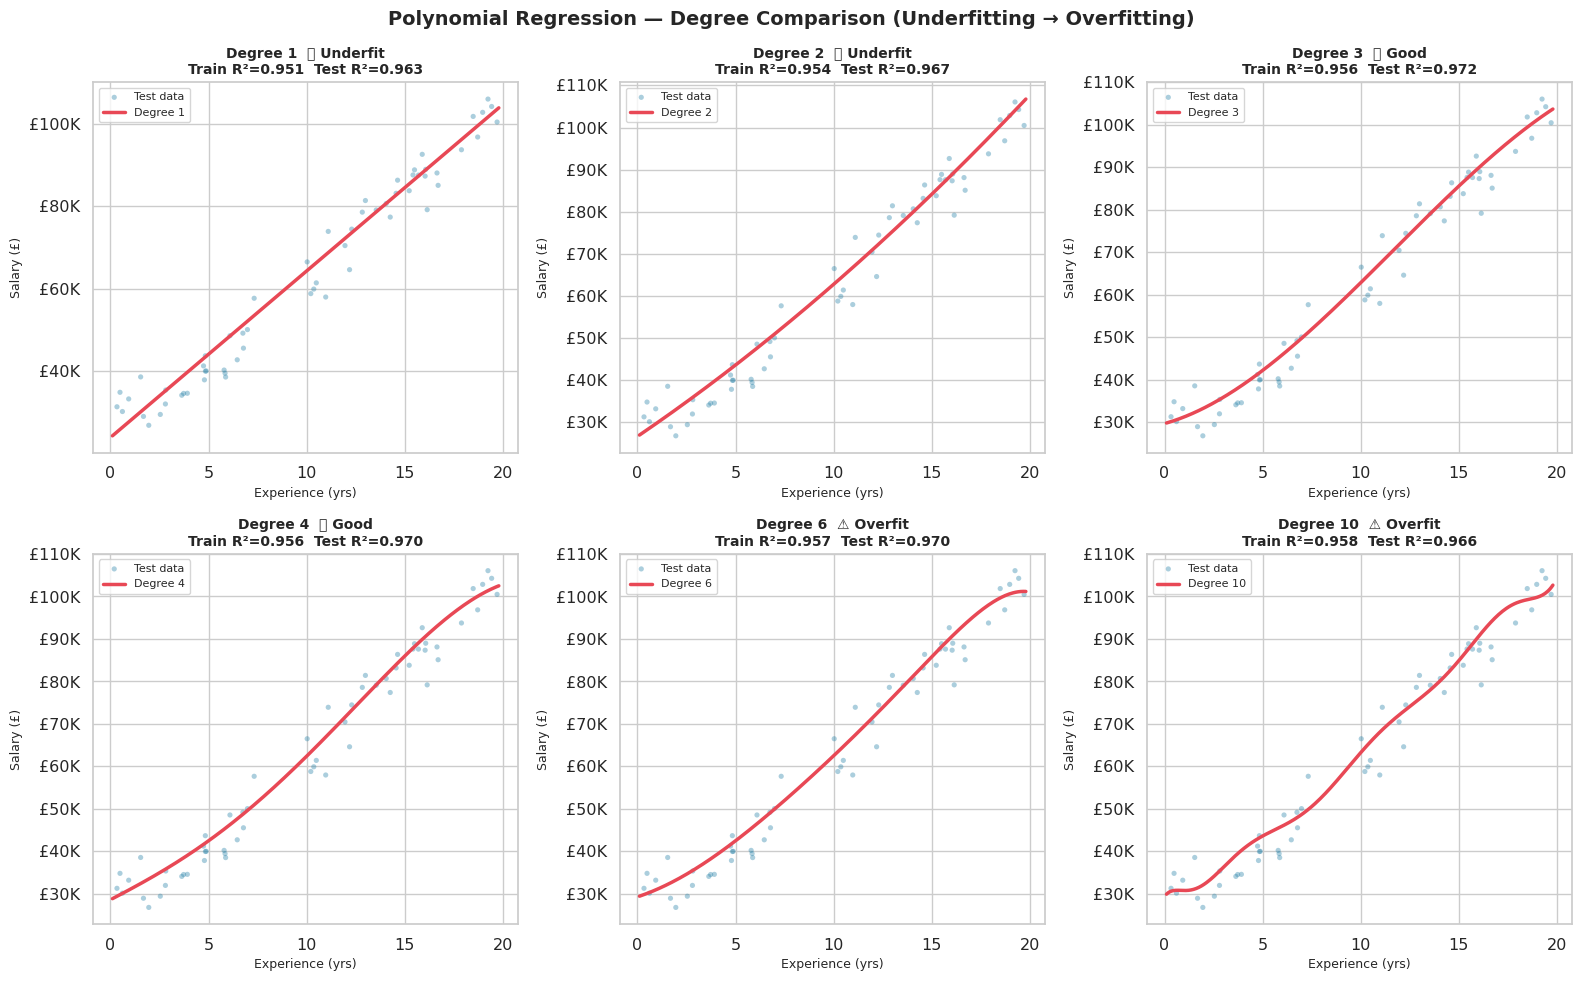

In [6]:
degrees    = [1, 2, 3, 4, 6, 10]
x_plot     = np.linspace(X['Experience'].min(), X['Experience'].max(), 300).reshape(-1, 1)

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.ravel()

for i, deg in enumerate(degrees):
    # Build pipeline
    pipe = Pipeline([
        ('poly' , PolynomialFeatures(degree=deg, include_bias=False)),
        ('scaler', StandardScaler()),
        ('model', LinearRegression()),
    ])
    pipe.fit(X_train, y_train)

    y_train_p = pipe.predict(X_train)
    y_test_p  = pipe.predict(X_test)
    train_r2  = r2_score(y_train, y_train_p)
    test_r2   = r2_score(y_test,  y_test_p)
    y_line    = pipe.predict(x_plot)

    axes[i].scatter(X_test, y_test,
                    color=COLORS['primary'], alpha=0.40, s=14,
                    edgecolors='none', label='Test data')
    axes[i].plot(x_plot, y_line,
                  color=COLORS['secondary'], linewidth=2.5,
                  label=f'Degree {deg}')
    axes[i].set_xlabel('Experience (yrs)', fontsize=9)
    axes[i].set_ylabel('Salary (£)', fontsize=9)
    axes[i].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x/1000:.0f}K'))
    status = '❌ Underfit' if deg <= 2 else ('✅ Good' if deg <= 4 else '⚠️ Overfit')
    axes[i].set_title(f'Degree {deg}  {status}\nTrain R²={train_r2:.3f}  Test R²={test_r2:.3f}',
                       fontsize=10, fontweight='bold')
    axes[i].legend(fontsize=8)

plt.suptitle('Polynomial Regression — Degree Comparison (Underfitting → Overfitting)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 5️⃣ Overfitting vs Underfitting

> | Degree | Bias | Variance | Issue |
> |--------|------|----------|-------|
> | Too low | High | Low | Underfitting — model too simple |
> | Just right | Low | Low | Good fit |
> | Too high | Low | High | Overfitting — model memorizes noise |

In [7]:
# ── Compute train vs test error for every degree 1–15 ────────────────────
max_deg   = 15
train_r2s = []
test_r2s  = []
train_rmses = []
test_rmses  = []

for deg in range(1, max_deg + 1):
    pipe = Pipeline([
        ('poly'  , PolynomialFeatures(degree=deg, include_bias=False)),
        ('scaler', StandardScaler()),
        ('model' , LinearRegression()),
    ])
    pipe.fit(X_train, y_train)
    y_tr = pipe.predict(X_train)
    y_te = pipe.predict(X_test)

    train_r2s.append(r2_score(y_train, y_tr))
    test_r2s.append(r2_score(y_test,  y_te))
    train_rmses.append(np.sqrt(mean_squared_error(y_train, y_tr)))
    test_rmses.append(np.sqrt(mean_squared_error(y_test,  y_te)))

results_df = pd.DataFrame({
    'Degree'    : range(1, max_deg + 1),
    'Train R²'  : np.round(train_r2s, 4),
    'Test R²'   : np.round(test_r2s, 4),
    'Train RMSE': np.round(train_rmses, 0),
    'Test RMSE' : np.round(test_rmses, 0),
})
print('Train vs Test Performance by Degree:')
print(results_df.to_string(index=False))

best_deg = results_df.loc[results_df['Test R²'].idxmax(), 'Degree']
print(f'\n🏆 Best Degree (highest Test R²): {best_deg}')

Train vs Test Performance by Degree:
 Degree  Train R²  Test R²  Train RMSE  Test RMSE
      1    0.9508   0.9631   5393.0000  4727.0000
      2    0.9537   0.9674   5229.0000  4442.0000
      3    0.9561   0.9716   5092.0000  4146.0000
      4    0.9563   0.9698   5078.0000  4274.0000
      5    0.9565   0.9696   5069.0000  4288.0000
      6    0.9565   0.9697   5069.0000  4284.0000
      7    0.9568   0.9695   5049.0000  4298.0000
      8    0.9572   0.9676   5029.0000  4428.0000
      9    0.9577   0.9661   4999.0000  4531.0000
     10    0.9578   0.9659   4995.0000  4542.0000
     11    0.9579   0.9649   4985.0000  4612.0000
     12    0.9579   0.9648   4985.0000  4616.0000
     13    0.9583   0.9651   4961.0000  4595.0000
     14    0.9585   0.9646   4948.0000  4629.0000
     15    0.9587   0.9639   4938.0000  4673.0000

🏆 Best Degree (highest Test R²): 3


---
## 6️⃣ Evaluation Metrics

> A comprehensive scorecard comparing the best polynomial model vs linear baseline.

📊 Regression Scorecard — Linear vs Polynomial (degree=3):
            Split       MAE      RMSE  MAPE %     R²  Adj. R²
   Linear — Train 4296.6100 5392.6800  8.0294 0.9508   0.9506
    Linear — Test 3906.0200 4726.9900  8.0146 0.9631   0.9625
Poly(d=3) — Train 4100.0900 5092.4300  7.7390 0.9561   0.9553
 Poly(d=3) — Test 3378.4900 4145.8900  6.5140 0.9716   0.9696


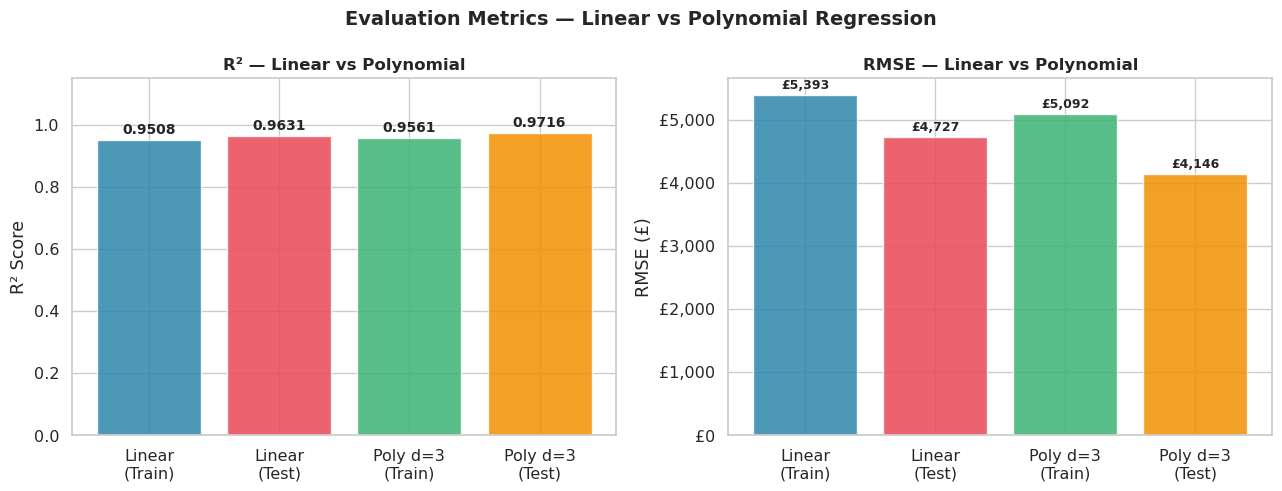

In [8]:
def regression_scorecard(y_true, y_pred, split_name, n_features):
    mse    = mean_squared_error(y_true, y_pred)
    r2     = r2_score(y_true, y_pred)
    n      = len(y_true)
    adj_r2 = 1 - (1 - r2) * (n - 1) / (n - n_features - 1)
    return {
        'Split'  : split_name,
        'MAE'    : round(mean_absolute_error(y_true, y_pred), 2),
        'RMSE'   : round(np.sqrt(mse), 2),
        'MAPE %' : round(mean_absolute_percentage_error(y_true, y_pred) * 100, 4),
        'R²'     : round(r2, 4),
        'Adj. R²': round(adj_r2, 4),
    }

# Best polynomial pipeline
best_pipe = Pipeline([
    ('poly'  , PolynomialFeatures(degree=int(best_deg), include_bias=False)),
    ('scaler', StandardScaler()),
    ('model' , LinearRegression()),
])
best_pipe.fit(X_train, y_train)
y_train_best = best_pipe.predict(X_train)
y_test_best  = best_pipe.predict(X_test)

n_poly_feats = PolynomialFeatures(degree=int(best_deg)).fit_transform(X_train).shape[1]

scorecard = pd.DataFrame([
    regression_scorecard(y_train, lin_model.predict(X_train), f'Linear — Train', 1),
    regression_scorecard(y_test,  y_lin_pred,                 f'Linear — Test',  1),
    regression_scorecard(y_train, y_train_best, f'Poly(d={best_deg}) — Train', n_poly_feats),
    regression_scorecard(y_test,  y_test_best,  f'Poly(d={best_deg}) — Test',  n_poly_feats),
])

print(f'📊 Regression Scorecard — Linear vs Polynomial (degree={best_deg}):')
print(scorecard.to_string(index=False))

# ── R² and RMSE comparison bar chart ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

models  = ['Linear\n(Train)', 'Linear\n(Test)', f'Poly d={best_deg}\n(Train)', f'Poly d={best_deg}\n(Test)']
r2_vals = scorecard['R²'].tolist()
rmse_vals = scorecard['RMSE'].tolist()
bar_colors = [COLORS['primary'], COLORS['secondary'], COLORS['accent'], COLORS['warning']]

bars = axes[0].bar(models, r2_vals, color=bar_colors, edgecolor='white', alpha=0.85)
axes[0].set_ylim(0, 1.15)
axes[0].set_ylabel('R² Score')
axes[0].set_title('R² — Linear vs Polynomial', fontsize=12, fontweight='bold')
for bar, val in zip(bars, r2_vals):
    axes[0].text(bar.get_x() + bar.get_width() / 2, val + 0.02,
                 f'{val:.4f}', ha='center', fontsize=10, fontweight='bold')

bars = axes[1].bar(models, rmse_vals, color=bar_colors, edgecolor='white', alpha=0.85)
axes[1].set_ylabel('RMSE (£)')
axes[1].set_title('RMSE — Linear vs Polynomial', fontsize=12, fontweight='bold')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
for bar, val in zip(bars, rmse_vals):
    axes[1].text(bar.get_x() + bar.get_width() / 2, val + 100,
                 f'£{val:,.0f}', ha='center', fontsize=9, fontweight='bold')

plt.suptitle('Evaluation Metrics — Linear vs Polynomial Regression',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 7️⃣ Bias-Variance Tradeoff

> The **sweet spot** is where test error is minimized.
>
> - **Left of the sweet spot:** High bias (underfitting) — both train and test error are high
> - **Right of the sweet spot:** High variance (overfitting) — train error drops but test error rises
>
> ✅ Plotting train vs test error by degree reveals this tradeoff visually.

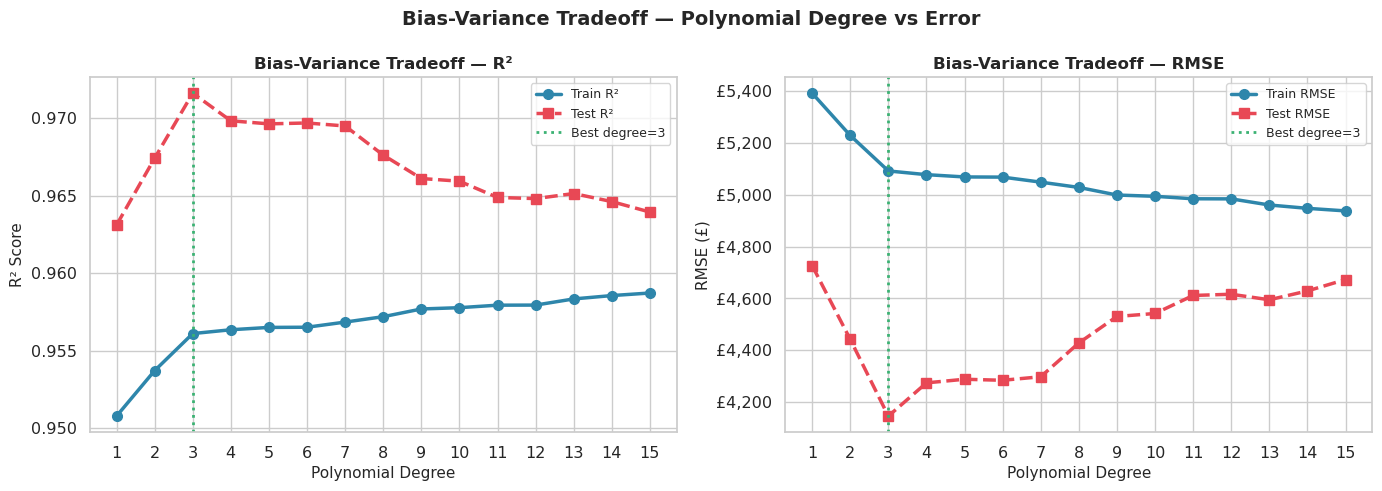

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
degrees_range = range(1, max_deg + 1)

# R² plot
axes[0].plot(degrees_range, train_r2s, 'o-',
              color=COLORS['primary'], linewidth=2.5, markersize=7, label='Train R²')
axes[0].plot(degrees_range, test_r2s, 's--',
              color=COLORS['secondary'], linewidth=2.5, markersize=7, label='Test R²')
axes[0].axvline(best_deg, color=COLORS['accent'], linewidth=2,
                 linestyle=':', label=f'Best degree={best_deg}')
axes[0].set_xlabel('Polynomial Degree', fontsize=11)
axes[0].set_ylabel('R² Score', fontsize=11)
axes[0].set_title('Bias-Variance Tradeoff — R²', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].set_xticks(list(degrees_range))

# RMSE plot
axes[1].plot(degrees_range, train_rmses, 'o-',
              color=COLORS['primary'], linewidth=2.5, markersize=7, label='Train RMSE')
axes[1].plot(degrees_range, test_rmses, 's--',
              color=COLORS['secondary'], linewidth=2.5, markersize=7, label='Test RMSE')
axes[1].axvline(best_deg, color=COLORS['accent'], linewidth=2,
                 linestyle=':', label=f'Best degree={best_deg}')
axes[1].set_xlabel('Polynomial Degree', fontsize=11)
axes[1].set_ylabel('RMSE (£)', fontsize=11)
axes[1].set_title('Bias-Variance Tradeoff — RMSE', fontsize=12, fontweight='bold')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
axes[1].legend(fontsize=9)
axes[1].set_xticks(list(degrees_range))

plt.suptitle('Bias-Variance Tradeoff — Polynomial Degree vs Error',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 8️⃣ Cross-Validation — Optimal Degree Selection

> A single train/test split can be **lucky or unlucky**.  
> K-Fold CV gives a **more reliable estimate** of the true best degree.
>
> ✅ Always use CV to choose hyperparameters like polynomial degree.

5-Fold Cross-Validation — R² and RMSE by Degree:
 Degree  CV R² Mean  CV R² Std  CV RMSE Mean  CV RMSE Std
      1      0.9515     0.0119     5272.0700     474.5600
      2      0.9547     0.0115     5095.3100     499.0100
      3      0.9574     0.0104     4949.2100     483.6300
      4      0.9569     0.0100     4981.4200     443.2800
      5      0.9565     0.0097     5009.7200     429.3200
      6      0.9565     0.0097     5010.3700     428.8500
      7      0.9564     0.0095     5013.4900     416.3400
      8      0.9557     0.0092     5061.0000     383.1600
      9      0.9556     0.0087     5070.4300     343.9500
     10      0.9556     0.0087     5069.8900     342.0100
     11      0.9550     0.0087     5100.1700     336.1300

🏆 Optimal Degree via CV: 3


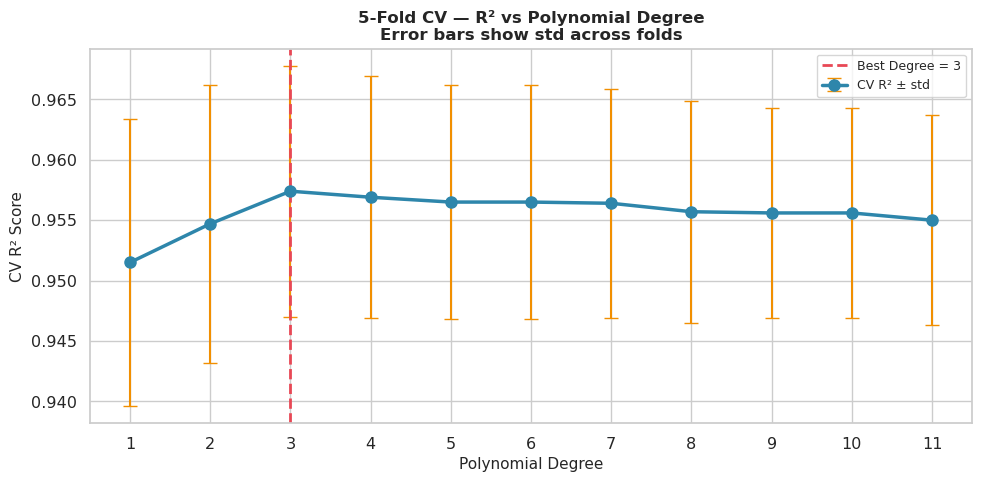

In [10]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_results = []
for deg in range(1, 12):
    pipe = Pipeline([
        ('poly'  , PolynomialFeatures(degree=deg, include_bias=False)),
        ('scaler', StandardScaler()),
        ('model' , LinearRegression()),
    ])
    r2_scores   = cross_val_score(pipe, X, y, cv=kf, scoring='r2')
    rmse_scores = np.sqrt(-cross_val_score(pipe, X, y, cv=kf,
                                            scoring='neg_mean_squared_error'))
    cv_results.append({
        'Degree'      : deg,
        'CV R² Mean'  : round(r2_scores.mean(), 4),
        'CV R² Std'   : round(r2_scores.std(), 4),
        'CV RMSE Mean': round(rmse_scores.mean(), 2),
        'CV RMSE Std' : round(rmse_scores.std(), 2),
    })

cv_df = pd.DataFrame(cv_results)
best_cv_deg = cv_df.loc[cv_df['CV R² Mean'].idxmax(), 'Degree']

print('5-Fold Cross-Validation — R² and RMSE by Degree:')
print(cv_df.to_string(index=False))
print(f'\n🏆 Optimal Degree via CV: {best_cv_deg}')

# ── CV R² plot ────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
ax.errorbar(cv_df['Degree'], cv_df['CV R² Mean'],
             yerr=cv_df['CV R² Std'],
             fmt='o-', color=COLORS['primary'], linewidth=2.5,
             markersize=8, elinewidth=1.5,
             ecolor=COLORS['warning'], capsize=5, label='CV R² ± std')
ax.axvline(best_cv_deg, color=COLORS['secondary'], linewidth=2,
            linestyle='--', label=f'Best Degree = {best_cv_deg}')
ax.set_xlabel('Polynomial Degree', fontsize=11)
ax.set_ylabel('CV R² Score', fontsize=11)
ax.set_title('5-Fold CV — R² vs Polynomial Degree\nError bars show std across folds',
              fontsize=12, fontweight='bold')
ax.set_xticks(cv_df['Degree'].tolist())
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

---
## 9️⃣ Polynomial + Ridge Regularization

> High-degree polynomial models can produce **wildly large coefficients** to fit noise.  
> **Ridge (L2 regularization)** penalizes large coefficients → smoother, more stable curves.
>
> **Ridge objective:**  
> `minimize: RSS + α × Σ(βᵢ²)`
>
> - `α = 0` → plain OLS  
> - `α → ∞` → all coefficients shrink to 0 (underfitting)
>
> ✅ For high-degree polynomials, **always try Ridge** before accepting a high-variance model.

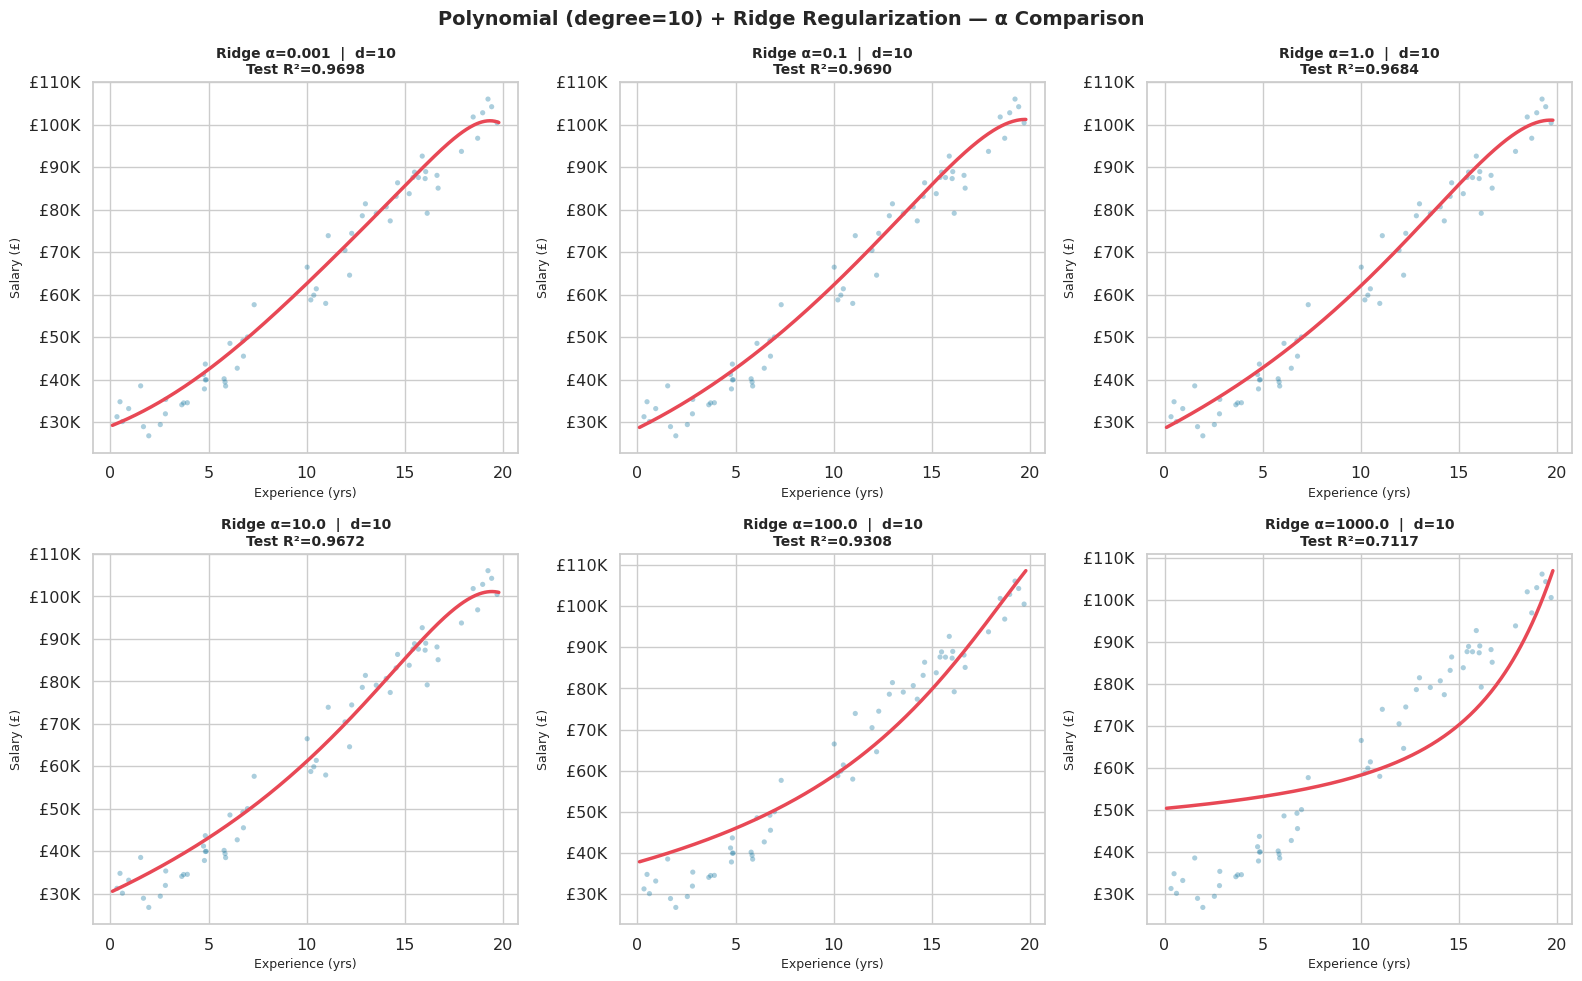

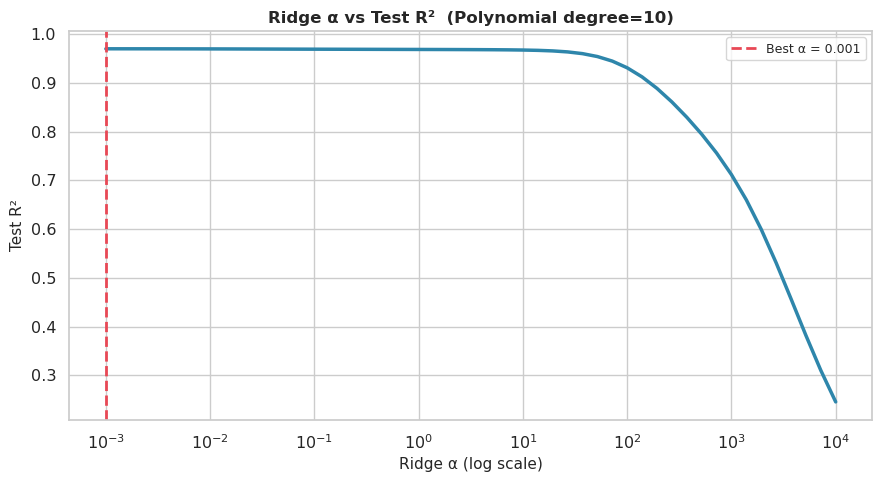

Best Ridge α: 0.0010  |  Best Test R²: 0.9698


In [11]:
high_deg  = 10
alphas    = [0.001, 0.1, 1.0, 10.0, 100.0, 1000.0]
x_plot    = np.linspace(X['Experience'].min(), X['Experience'].max(), 300).reshape(-1, 1)

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.ravel()

for i, alpha in enumerate(alphas):
    pipe = Pipeline([
        ('poly'  , PolynomialFeatures(degree=high_deg, include_bias=False)),
        ('scaler', StandardScaler()),
        ('model' , Ridge(alpha=alpha)),
    ])
    pipe.fit(X_train, y_train)
    y_te   = pipe.predict(X_test)
    y_line = pipe.predict(x_plot)
    test_r2 = r2_score(y_test, y_te)

    axes[i].scatter(X_test, y_test,
                    color=COLORS['primary'], alpha=0.40, s=14, edgecolors='none')
    axes[i].plot(x_plot, y_line,
                  color=COLORS['secondary'], linewidth=2.5)
    axes[i].set_xlabel('Experience (yrs)', fontsize=9)
    axes[i].set_ylabel('Salary (£)', fontsize=9)
    axes[i].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x/1000:.0f}K'))
    axes[i].set_title(f'Ridge α={alpha}  |  d={high_deg}\nTest R²={test_r2:.4f}',
                       fontsize=10, fontweight='bold')

plt.suptitle(f'Polynomial (degree={high_deg}) + Ridge Regularization — α Comparison',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ── R² vs alpha ───────────────────────────────────────────────────────────
alpha_range = np.logspace(-3, 4, 50)
r2_alphas   = []
for alpha in alpha_range:
    pipe = Pipeline([
        ('poly'  , PolynomialFeatures(degree=high_deg, include_bias=False)),
        ('scaler', StandardScaler()),
        ('model' , Ridge(alpha=alpha)),
    ])
    pipe.fit(X_train, y_train)
    r2_alphas.append(r2_score(y_test, pipe.predict(X_test)))

best_alpha = alpha_range[np.argmax(r2_alphas)]

fig, ax = plt.subplots(figsize=(9, 5))
ax.semilogx(alpha_range, r2_alphas, color=COLORS['primary'], linewidth=2.5)
ax.axvline(best_alpha, color=COLORS['secondary'], linewidth=2,
            linestyle='--', label=f'Best α = {best_alpha:.3f}')
ax.set_xlabel('Ridge α (log scale)', fontsize=11)
ax.set_ylabel('Test R²', fontsize=11)
ax.set_title(f'Ridge α vs Test R²  (Polynomial degree={high_deg})',
              fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print(f'Best Ridge α: {best_alpha:.4f}  |  Best Test R²: {max(r2_alphas):.4f}')

---
## 🔟 Multi-Feature Polynomial Regression

> With multiple input features, `PolynomialFeatures` also generates **interaction terms**.  
>
> For 2 features `[x₁, x₂]` at degree=2:  
> `[x₁, x₂]` → `[x₁, x₂, x₁², x₁·x₂, x₂²]`  
>
> ⚠️ Feature count grows **combinatorially** — be careful with many features + high degree.

In [12]:
# ── Multi-feature dataset ─────────────────────────────────────────────────
np.random.seed(42)
n_multi = 500

exp_m   = np.random.uniform(0, 20, n_multi)
score_m = np.random.uniform(40, 100, n_multi)
age_m   = np.random.randint(22, 60, n_multi).astype(float)

salary_m = (
    25_000
    + 1_200 * exp_m
    + 150   * exp_m**2
    + 400   * score_m
    - 3     * score_m**2
    + 200   * age_m
    + 50    * exp_m * score_m   # interaction term
    + np.random.normal(0, 7_000, n_multi)
)

df_multi = pd.DataFrame({
    'Experience': exp_m,
    'Score'     : score_m,
    'Age'       : age_m,
    'Salary'    : salary_m.astype(int),
})

X_m = df_multi[['Experience', 'Score', 'Age']]
y_m = df_multi['Salary']

X_m_train, X_m_test, y_m_train, y_m_test = train_test_split(
    X_m, y_m, test_size=0.2, random_state=42
)

# ── Feature expansion summary ─────────────────────────────────────────────
print('Feature count explosion with degree and number of features:')
print(f'{"Degree":>8} | {"# Original":>12} | {"# After Poly":>14}')
print('-' * 40)
for deg in range(1, 6):
    poly = PolynomialFeatures(degree=deg, include_bias=False)
    n_out = poly.fit_transform(X_m_train).shape[1]
    print(f'{deg:>8} | {X_m_train.shape[1]:>12} | {n_out:>14}')

# ── Compare degrees on multi-feature data ─────────────────────────────────
print('\nMulti-Feature Polynomial Regression — CV Performance by Degree:')
multi_cv = []
for deg in range(1, 5):
    pipe = Pipeline([
        ('poly'  , PolynomialFeatures(degree=deg, include_bias=False)),
        ('scaler', StandardScaler()),
        ('model' , Ridge(alpha=1.0)),
    ])
    r2s = cross_val_score(pipe, X_m, y_m,
                          cv=KFold(n_splits=5, shuffle=True, random_state=42),
                          scoring='r2')
    pipe.fit(X_m_train, y_m_train)
    test_r2 = r2_score(y_m_test, pipe.predict(X_m_test))
    n_feats = PolynomialFeatures(degree=deg).fit_transform(X_m_train).shape[1]
    multi_cv.append({
        'Degree'    : deg,
        '# Features': n_feats,
        'CV R² Mean': round(r2s.mean(), 4),
        'CV R² Std' : round(r2s.std(), 4),
        'Test R²'   : round(test_r2, 4),
    })

print(pd.DataFrame(multi_cv).to_string(index=False))

Feature count explosion with degree and number of features:
  Degree |   # Original |   # After Poly
----------------------------------------
       1 |            3 |              3
       2 |            3 |              9
       3 |            3 |             19
       4 |            3 |             34
       5 |            3 |             55

Multi-Feature Polynomial Regression — CV Performance by Degree:
 Degree  # Features  CV R² Mean  CV R² Std  Test R²
      1           4      0.9576     0.0053   0.9641
      2          10      0.9756     0.0030   0.9766
      3          20      0.9754     0.0028   0.9763
      4          35      0.9751     0.0029   0.9762


---
## 1️⃣1️⃣ sklearn Pipeline — Scale + Poly + Fit

> The **cleanest production workflow** for polynomial regression:
>
> ```
> Raw X  →  PolynomialFeatures  →  StandardScaler  →  Ridge/LinearRegression  →  ŷ
> ```
>
> ✅ Pipelines prevent **data leakage** in cross-validation —  
> the polynomial expansion and scaling are refitted on each training fold.

Final Pipeline: PolynomialFeatures(d=3) + StandardScaler + Ridge(α=0.001)

5-Fold CV Results:
  R²   : 0.9574 ± 0.0104
  RMSE : £4,949 ± £484

Test Set Performance:
  R²   : 0.9716
  RMSE : £4,146
  MAE  : £3,379


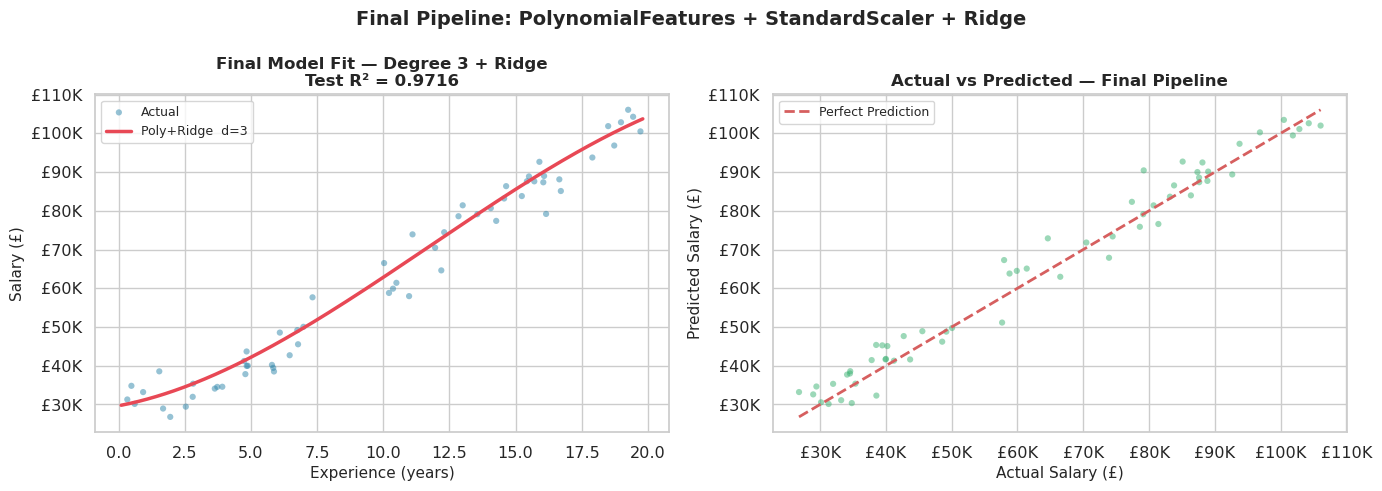


✅ Pipeline ensures poly expansion and scaling are fit on train only in every fold — no leakage!


In [13]:
optimal_degree = int(best_cv_deg)
optimal_alpha  = float(best_alpha)

final_pipeline = Pipeline([
    ('poly'  , PolynomialFeatures(degree=optimal_degree, include_bias=False)),
    ('scaler', StandardScaler()),
    ('model' , Ridge(alpha=optimal_alpha)),
])

final_pipeline.fit(X_train, y_train)
y_final_pred = final_pipeline.predict(X_test)

# Cross-validate the full pipeline
kf_final   = KFold(n_splits=5, shuffle=True, random_state=42)
pipe_r2    = cross_val_score(final_pipeline, X, y, cv=kf_final, scoring='r2')
pipe_rmse  = np.sqrt(-cross_val_score(final_pipeline, X, y, cv=kf_final,
                                       scoring='neg_mean_squared_error'))

print(f'Final Pipeline: PolynomialFeatures(d={optimal_degree}) + StandardScaler + Ridge(α={optimal_alpha:.3f})')
print(f'\n5-Fold CV Results:')
print(f'  R²   : {pipe_r2.mean():.4f} ± {pipe_r2.std():.4f}')
print(f'  RMSE : £{pipe_rmse.mean():,.0f} ± £{pipe_rmse.std():,.0f}')
print(f'\nTest Set Performance:')
print(f'  R²   : {r2_score(y_test, y_final_pred):.4f}')
print(f'  RMSE : £{np.sqrt(mean_squared_error(y_test, y_final_pred)):,.0f}')
print(f'  MAE  : £{mean_absolute_error(y_test, y_final_pred):,.0f}')

# ── Final fit visualization ───────────────────────────────────────────────
x_plot = np.linspace(X['Experience'].min(), X['Experience'].max(), 300).reshape(-1, 1)
y_final_line = final_pipeline.predict(x_plot)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Fit curve
axes[0].scatter(X_test, y_test,
                color=COLORS['primary'], alpha=0.50, s=20, edgecolors='none', label='Actual')
axes[0].plot(x_plot, y_final_line,
              color=COLORS['secondary'], linewidth=2.5,
              label=f'Poly+Ridge  d={optimal_degree}')
axes[0].set_xlabel('Experience (years)', fontsize=11)
axes[0].set_ylabel('Salary (£)', fontsize=11)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x/1000:.0f}K'))
axes[0].set_title(f'Final Model Fit — Degree {optimal_degree} + Ridge\n'
                   f'Test R² = {r2_score(y_test, y_final_pred):.4f}',
                   fontsize=12, fontweight='bold')
axes[0].legend(fontsize=9)

# Actual vs Predicted
axes[1].scatter(y_test, y_final_pred,
                color=COLORS['accent'], alpha=0.50, s=20, edgecolors='none')
mn = min(y_test.min(), y_final_pred.min())
mx = max(y_test.max(), y_final_pred.max())
axes[1].plot([mn, mx], [mn, mx], 'r--', linewidth=2, label='Perfect Prediction')
axes[1].set_xlabel('Actual Salary (£)', fontsize=11)
axes[1].set_ylabel('Predicted Salary (£)', fontsize=11)
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x/1000:.0f}K'))
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x/1000:.0f}K'))
axes[1].set_title('Actual vs Predicted — Final Pipeline',
                   fontsize=12, fontweight='bold')
axes[1].legend(fontsize=9)

plt.suptitle('Final Pipeline: PolynomialFeatures + StandardScaler + Ridge',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('\n✅ Pipeline ensures poly expansion and scaling are fit on train only in every fold — no leakage!')

---
## ✅ 12. Summary & Best Practices

| Aspect | Key Point |
|--------|----------|
| **When to use** | When scatter plots show non-linear (curved) X–y relationship |
| **Mechanism** | Expand features with `PolynomialFeatures`, then apply LinearRegression |
| **Degree selection** | Use K-Fold CV — never pick degree by train error alone |
| **Overfitting risk** | High degree → very large coefficients, wiggly curves |
| **Fix for overfitting** | Add Ridge (L2) regularization — tune α via CV |
| **Multi-feature warning** | Feature count explodes combinatorially with degree |
| **Pipeline** | Always wrap poly + scaler + model in a Pipeline for CV safety |
| **Evaluation** | Use Adj. R² (penalizes extra features), RMSE, MAE |

### 🔑 Golden Rules

1. **Always plot X vs y first** — confirm non-linearity before reaching for polynomials
2. **Start simple** — try degree 2–4 before jumping to higher degrees
3. **Train error always improves** with degree — test error is the only honest signal
4. **Use CV to select degree** — single train/test split is unreliable
5. **Pair high-degree polynomials with Ridge** — prevents explosive coefficients
6. **Wrap everything in a Pipeline** — prevents data leakage from scaler and poly transform
7. **Watch feature count** — 3 features at degree 5 → 55 features; 10 features → thousands
8. **Never extrapolate** — polynomial curves diverge rapidly outside the training range

---

## 🔗 Next Steps

- ➡️ `Ridge_Regression/` — L2 regularization for multicollinearity and overfitting control
- ➡️ `Lasso_Regression/` — L1 regularization for automatic feature selection
- ➡️ `ElasticNet_Regression/` — Combined L1+L2 penalty
- ➡️ `05_Model_Evaluation/regression_metrics` — Full metric deep-dive
- ➡️ `07_Hyperparameter_Tuning/` — Tune degree and α jointly via GridSearchCV